In [1]:
import re, os
import scanpy as sc
import torch
import numpy as np
import pandas as pd
import sys
import bound as bd
import plot_mouse as plot 
import scvi
from pathlib import Path
import importlib
sys.path.append('/home/zhouyj/stVirtual/src')
import stVirtual_model.ode_multislice as s1
import stVirtual_model.rl_multislice as s2
import utils.save_uot as sv1
import utils.save_rl as sv2

In [2]:
data_path = '/home/zhouyj/stVirtual/data/Mbrain/processed'
ckpt_path = '/home/zhouyj/stVirtual/src/Mbrain/Mbrain_ckpt'
resl_path = '/home/zhouyj/stVirtual/src/Mbrain/Mbrain_results'
lrpr_path = '/home/zhouyj/stVirtual/data/lrpairs/mouse/LR_pairs.csv'

In [3]:
route_ids=['T170', 'T171']
fracs = ["T170_to_T171"]
seg_key = "T170_to_T171" 
steps = 10

In [4]:
adata = sc.read_h5ad(f"{data_path}/Mbrain.h5ad")
adata

AnnData object with n_obs × n_vars = 152586 × 19547
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'region', 'coor_x', 'coor_y', 'raw_x', 'raw_y', 'distance', 'area', 'Astrocyte', 'Bergmann', 'Choroid', 'Endothelial_mural', 'Endothelial_stalk', 'Ependymal', 'Fibroblast', 'Golgi', 'Granule', 'MLI1', 'MLI2', 'Macrophage', 'Microglia', 'ODC', 'OPC', 'PLI', 'Purkinje', 'UBC', 'cluster', 'annotation', 'sample', 'n_genes', '_scvi_batch', '_scvi_labels', 'leiden_scVI', 'cx_aligned', 'cy_aligned', 'cx_aligned_norm', 'cy_aligned_norm', 'LR_potential', 'LR_potential_z', 'LR_potential_z_smooth', 'LR_potential_z_smooth_w'
    var: 'n_counts'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'annotation_colors', 'leiden_scVI', 'leiden_scVI_colors', 'log1p', 'neighbors', 'pca', 'sample_colors', 'umap'
    obsm: 'X_pca', 'X_scanVI', 'X_umap', 'spatial'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [5]:
adata.obs['sample'].unique()

['T167', 'T168', 'T169', 'T170', 'T171']
Categories (5, object): ['T167', 'T168', 'T169', 'T170', 'T171']

In [6]:
plot.plot_spatial_stack_3d(adata)

/home/zhouyj/stVirtual/src/Mbrain/plot_mouse.py:423: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


[OK] saved: spatial_stack_3d.png | samples: 5 | points: 152586


In [7]:
model_dir = f"{ckpt_path}/scvi/scanvi"
model = scvi.model.SCANVI.load(model_dir, adata=adata)

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


INFO     File /home/zhouyj/stVirtual/src/Mbrain/Mbrain_ckpt/scvi/scanvi/model.pt already downloaded                


In [ ]:
importlib.reload(s1)

res1 = s1.train_model_multislice(
    model=model,                  
    adata_all=adata,
    slice_key="sample",
    route_ids=route_ids,
    save_root=f"{ckpt_path}/res1_all",
    x_key="cx_aligned",
    y_key="cy_aligned",
    latent_layer="X_scanVI",    
    steps=steps,  
    guide_eps=0.005,
    uot_eps=0.05, uot_tau=1.0 , uot_lam_x=2.0, uot_lam_f=0.1,
    guide_topk=512, guide_temp=0.5, guide_schedule="linear",
    cell_type_key='annotation',
    lam_context=5.0,
    lam_residual=0.1,
    lam_vsmooth=0.1,  
    lam_uot=1.0,
    lib_layer='counts',              
    latent_dim=10,             
    epochs=100,
    device="cuda:0",
)

INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             

[MultiSlice] Train segment: T170_to_T171 (n_src=34874, n_tgt=46099)
  Global norm route_ids=['T170', 'T171']  latent_dim=10

Pre-computing neighbor context features...
[ctx] scale 1/1: sparse matmul ...  (E=557984)
[ctx] scale 1/1: sparse matmul ...  (E=737584)
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


Train (NeuralODE dopri5): 100%|██████████| 100/100 [02:01<00:00,  1.22s/it, loss=0.0113, uot=0.0077, vs=0.0338]


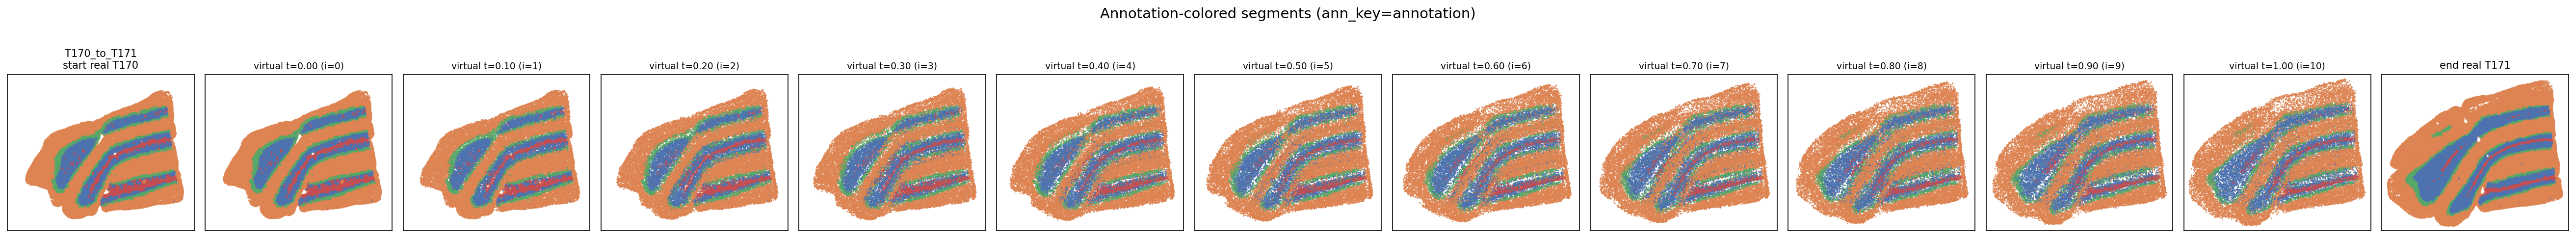

In [10]:
importlib.reload(plot)
fig = plot.plot_allframes(
    res1, adata,
    layout="horizontal", # or vertical show 
    route_ids=route_ids,
    ann_key="annotation",
    steps=steps,
    n_show=200000,
)

In [11]:
from utils.traj_ana import rollout_trace_from_out

OUT_STAGE1 = f"{ckpt_path}/stage1_res"

saved = sv1.save_res(
    res1=res1,
    adata_all=adata,
    out_dir=OUT_STAGE1,
    slice_key="sample",
    ann_key="annotation",
    save_prefix="rollout_stage1",
    steps=10,
    n_cache=256,
    unnormalize=False,
)

print(saved)

{'T170_to_T171': '/home/zhouyj/stVirtual/src/Mbrain/Mbrain_ckpt/stage1_res/rollout_stage1_T170_to_T171.npz'}


In [12]:
importlib.reload(bd)
def u_to_int(u: str) -> int:
    m = re.search(r"\d+", str(u))
    if m is None:
        raise ValueError(f"cannot parse number from {u}")
    return int(m.group(0))

def parse_frac(k: str):
    a, b = k.split("_to_")
    a = str(a); b = str(b)
    ai = u_to_int(a); bi = u_to_int(b)
    return a, b, ai, bi

fracs_sorted = sorted(fracs, key=lambda k: parse_frac(k)[2])
z_base = 0

alpha_factor = 3.2
target_frac = 0.99
expand0 = 1.02
expand_step = 0.01
expand_max = 1.30
n_resample = 256
n_cache = 256

bound_dir = Path(f"{resl_path}/bound")

for i, fk in enumerate(fracs_sorted):
    a, b, ai, bi = parse_frac(fk)
    trace = rollout_trace_from_out(res1[fk], steps=steps, n_cache=n_cache, unnormalize=False)
    coords_frames = [x.detach().cpu().numpy().astype(np.float32) for x in trace["x"]]
    out_dir = bound_dir / fk
    out_dir.mkdir(parents=True, exist_ok=True)
    stats = []
    print(f"\n=== {fk} | frames={len(coords_frames)} | alpha_factor={alpha_factor} | target={target_frac} ===")
    for k, xy in enumerate(coords_frames):
        shell, frac, out_idx, exp_used = bd.make_shell_adaptive(
            xy, alpha_factor=alpha_factor, seed=2026 + ai + k,
            n_resample=n_resample, target_frac=target_frac,
            expand0=expand0, expand_step=expand_step, expand_max=expand_max, fallback_expand=1.05
        )
        csv_path = out_dir / f"bound_z{0 + k:03d}.csv"
        png_path = out_dir / f"bound_z{0 + k:03d}.png"
        bd.save_shell_csv(shell, csv_path)
        bd.plot_shell_coverage(xy, shell, out_idx, png_path)
        n_out = int(out_idx.shape[0])
        print(f"[{fk}] frame {k:02d}: N={xy.shape[0]:6d}  frac_in={frac:.4f}  out={n_out:5d}  expand={exp_used}")
        stats.append({"frac": fk, "frame": k, "N": int(xy.shape[0]), "frac_in": float(frac), "n_out": n_out, "expand": float(exp_used) if exp_used==exp_used else np.nan,
                      "csv": str(csv_path), "png": str(png_path)})
    df = pd.DataFrame(stats)
    df.to_csv(out_dir / "bound_stats.csv", index=False)
    print(f"[{fk}] done. min_frac_in={df['frac_in'].min():.4f} max_out={df['n_out'].max()}")

print("all fracs done ->", bound_dir)


=== T170_to_T171 | frames=11 | alpha_factor=3.2 | target=0.99 ===
[T170_to_T171] frame 00: N= 34874  frac_in=0.9998  out=    8  expand=1.02
[T170_to_T171] frame 01: N= 34874  frac_in=0.9999  out=    2  expand=1.02
[T170_to_T171] frame 02: N= 34874  frac_in=0.9999  out=    2  expand=1.02
[T170_to_T171] frame 03: N= 34874  frac_in=0.9999  out=    3  expand=1.02
[T170_to_T171] frame 04: N= 34874  frac_in=0.9998  out=    7  expand=1.02
[T170_to_T171] frame 05: N= 34874  frac_in=0.9999  out=    3  expand=1.02
[T170_to_T171] frame 06: N= 34874  frac_in=0.9997  out=    9  expand=1.02
[T170_to_T171] frame 07: N= 34874  frac_in=0.9997  out=    9  expand=1.02
[T170_to_T171] frame 08: N= 34874  frac_in=0.9998  out=    6  expand=1.02
[T170_to_T171] frame 09: N= 34874  frac_in=0.9996  out=   14  expand=1.02
[T170_to_T171] frame 10: N= 34874  frac_in=0.9997  out=    9  expand=1.02
[T170_to_T171] done. min_frac_in=0.9996 max_out=14
all fracs done -> /home/zhouyj/stVirtual/src/Mbrain/Mbrain_results/b

In [13]:
## You only need to train the ODE once; 
## after that, the saved .npz file can be loaded directly, 
## avoiding retraining.

# saved = {'T170_to_T171': '/home/zhouyj/project/src/mouse_ckpt copy/stage1_res/rollout_stage1_T170_to_T171.npz'}

# RL training

In [ ]:
importlib.reload(s2)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

ctx = s2.build_global_ctx(
    adata_path=f"{data_path}/Mbrain.h5ad",
    lr_pairs_path=lrpr_path,
    ckpt_3dslice=f"{ckpt_path}/res1_all/T170_to_T171/checkpoints/best.pt",        
    device=device,
    layer_col="annotation",
)

stages = []
for sk in fracs:
    src, tgt = sk.split("_to_", 1)
    stages.append(
        s2.StageCfg(
            src=src,
            tgt=tgt,
            out_npz_path=saved[sk],
            bound_dir=f"{resl_path}/bound/{sk}",
            stat_json=f"{ckpt_path}/exp_decoder/decoder_counts_pair_{src}_{tgt}.json",
            ckpt_path_dec=f"{ckpt_path}/exp_decoder/decoder_counts_pair_{src}_{tgt}.pt",
            scanvi_dir=f"{ckpt_path}/scvi/scanvi",
            model_type="scanvi",
            use_lr=True,
            lr_source="decoder",
            use_latent=True,
            latent_fallback_obsm="X_scanVI",
            latent_fallback_layer="counts",
            layer_col="annotation"
        )
    )

outs = s2.run_multi_stages(
    ctx=ctx, sample_key='sample',
    stages=stages,
    best_ckpt_dir=f"{ckpt_path}/policy_ckpt_mouse",
    train_kwargs=dict(EPOCHS=100, LR=1e-4),
    W_XY_TGT=2.0, W_Z_TGT=0.05,
)

for o in outs:
    print(o["best_ckpt_path"])

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


LOADING latent model from: /home/zhouyj/stVirtual/src/Mbrain/Mbrain_ckpt/scvi/scanvi
INFO     File /home/zhouyj/stVirtual/src/Mbrain/Mbrain_ckpt/scvi/scanvi/model.pt already downloaded                


Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.


[warn] load(model_dir) failed without adata: Save path contains no saved anndata and no adata was passed.
INFO     File /home/zhouyj/stVirtual/src/Mbrain/Mbrain_ckpt/scvi/scanvi/model.pt already downloaded                
[latent] loaded scanvi with load_ref_adata (training schema)
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
[Grid] H=208, W=260, H×W=54080
[auto cap] 2 {'src': {'q': 0.9, 'quantile_value': 2.0, 'mean': 1.2095750570297241, 'max': 2.0, 'n_cells_used': 28825}, 'tgt': {'q': 0.9, 'quantile_value': 2.0, 'mean': 1.4683842658996582, 'max': 2.0, 'n_cells_used': 31361}, 'cap0': 2, 'capT': 2, 'cap': 2}


Training: 100%|██████████| 100/100 [16:44<00:00, 10.04s/it, rew=-0.5518, best=-0.5510, tgt=0.4827, occ=0.6709]

/home/zhouyj/stVirtual/src/Mbrain/Mbrain_ckpt/policy_ckpt_mouse/policy_T170_to_T171.pt


In [15]:
ckpt_map = {}
for o in outs:
    cfg = o["stage"]
    ckpt_map[f"{cfg.src}_to_{cfg.tgt}"] = o["best_ckpt_path"]

ckpt_map

{'T170_to_T171': '/home/zhouyj/stVirtual/src/Mbrain/Mbrain_ckpt/policy_ckpt_mouse/policy_T170_to_T171.pt'}

In [16]:
importlib.reload(s2)
rollouts = {}
for cfg in stages:
    seg_key = f"{cfg.src}_to_{cfg.tgt}"
    rollouts[seg_key] = s2.rollout_policy_one_stage(
        s2, ctx, cfg, ckpt_map[seg_key], 
        seed=2026, ADVECT_LATENT=True,
    )
    print(seg_key, "Tp1=", len(rollouts[seg_key]["coords"]))

LOADING latent model from: /home/zhouyj/stVirtual/src/Mbrain/Mbrain_ckpt/scvi/scanvi
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        
[Grid] H=208, W=260, H×W=54080
[auto cap] 2 {'src': {'q': 0.9, 'quantile_value': 2.0, 'mean': 1.2095750570297241, 'max': 2.0, 'n_cells_used': 28825}, 'tgt': {'q': 0.9, 'quantile_value': 2.0, 'mean': 1.4683842658996582, 'max': 2.0, 'n_cells_used': 31361}, 'cap0': 2, 'capT': 2, 'cap': 2}
T170_to_T171 Tp1= 11


In [17]:
importlib.reload(plot)

fig = plot.plot_allframes_policy(
    rollouts, adata, ctx,
    route_ids=route_ids,
    steps=steps,  
    s=2,       
    ann_key="annotation",
    show_birth=False,
    layout="horizontal",
    save_path=f"{resl_path}/policy_ckpt_mouse/plot_170_171.png",
    transparent=True,
)

[OK] saved: /home/zhouyj/stVirtual/src/Mbrain/Mbrain_results/policy_ckpt_mouse/plot_170_171.png


In [18]:
ro = rollouts[seg_key]

for t in range(len(ro["coords"])):
    N  = int(np.asarray(ro["coords"][t]).shape[0])
    nb = int(np.asarray(ro["is_birth"][t]).sum())  
    print(f"{seg_key} | t={t:02d} | N={N} | new_birth={nb}")

npz_path = '/home/zhouyj/stVirtual/src/Mbrain/Mbrain_ckpt/stage2_res/rollout_stage2_T170_to_T171.npz'
os.makedirs(os.path.dirname(npz_path), exist_ok=True)
np.savez_compressed(npz_path, rollouts=np.array(rollouts, dtype=object))
print("saved:", npz_path)

T170_to_T171 | t=00 | N=34874 | new_birth=0
T170_to_T171 | t=01 | N=35975 | new_birth=5472
T170_to_T171 | t=02 | N=37080 | new_birth=5475
T170_to_T171 | t=03 | N=38189 | new_birth=5659
T170_to_T171 | t=04 | N=39302 | new_birth=5833
T170_to_T171 | t=05 | N=40421 | new_birth=6034
T170_to_T171 | t=06 | N=41545 | new_birth=6275
T170_to_T171 | t=07 | N=42675 | new_birth=6602
T170_to_T171 | t=08 | N=43811 | new_birth=7084
T170_to_T171 | t=09 | N=44941 | new_birth=7573
T170_to_T171 | t=10 | N=46099 | new_birth=8198
saved: /home/zhouyj/stVirtual/src/Mbrain/Mbrain_ckpt/stage2_res/rollout_stage2_T170_to_T171.npz


In [19]:
importlib.reload(sv2)
out_dir = "/home/zhouyj/stVirtual/src/Mbrain/Mbrain_results/rollout_h5ad_mouse"

sv2.save_all_rollouts_as_h5ad(
    rollouts, stages, ctx,
    out_dir,
    save_which="all",
    frame_stride=1,   
    make_sparse=False,
)

[done] saved to /home/zhouyj/stVirtual/src/Mbrain/Mbrain_results/rollout_h5ad_mouse
